In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
sns.set_theme(style="white")

In [5]:
np.random.seed(42)
num_interacciones = 50000
usuarios = np.random.randint(1, 1000, num_interacciones) # 1000 estudiantes
recursos = np.random.randint(1, 500, num_interacciones)  # 500 recursos disponibles
ratings = np.random.randint(1, 6, num_interacciones)     # Calificaciones del 1 al 5

df_interacciones = pd.DataFrame({
    'ID_Usuario': usuarios,
    'ID_Recurso': recursos,
    'Rating': ratings
})

df_interacciones = df_interacciones.drop_duplicates(subset=['ID_Usuario', 'ID_Recurso'], keep='last')

matriz_usuario_recurso = df_interacciones.pivot(index='ID_Recurso', columns='ID_Usuario', values='Rating').fillna(0)
svd = TruncatedSVD(n_components=20, random_state=42)
matriz_comprimida = svd.fit_transform(matriz_usuario_recurso)

matriz_correlacion = np.corrcoef(matriz_comprimida)

print("--- MATRIZ SVD ENTRENADA ---")
print(f"Dimensiones originales: {matriz_usuario_recurso.shape}")
print(f"Dimensiones comprimidas (SVD): {matriz_comprimida.shape}")

def recomendar_por_comportamiento(id_recurso_visto, top_n=5):
    indice_recurso = list(matriz_usuario_recurso.index).index(id_recurso_visto)
    correlaciones = matriz_correlacion[indice_recurso]
    df_resultados = pd.DataFrame({
        'ID_Recurso_Recomendado': matriz_usuario_recurso.index,
        'Correlacion': correlaciones
    })
    
    recomendaciones = df_resultados[df_resultados['ID_Recurso_Recomendado'] != id_recurso_visto].sort_values(
        by='Correlacion', ascending=False
    ).head(top_n)
    
    return recomendaciones

recurso_objetivo = 150

print(f"\n--- ESTUDIANTES QUE VIERON EL RECURSO {recurso_objetivo} TAMBIÉN VIERON: ---")
recomendaciones_svd = recomendar_por_comportamiento(recurso_objetivo, top_n=5)
recomendaciones_svd.head()

--- MATRIZ SVD ENTRENADA ---
Dimensiones originales: (499, 999)
Dimensiones comprimidas (SVD): (499, 20)

--- ESTUDIANTES QUE VIERON EL RECURSO 150 TAMBIÉN VIERON: ---


,ID_Recurso_Recomendado,Correlacion
43,44,0.790560
265,266,0.784610
392,393,0.762682
470,471,0.759998
272,273,0.756499


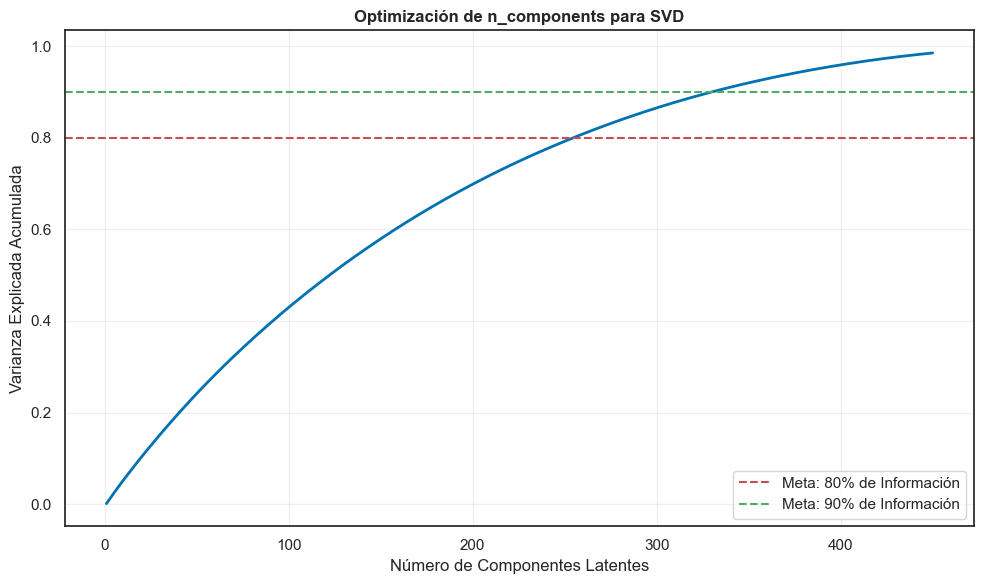

Componentes para retener el 80% de información: 255
Componentes para retener el 90% de información: 330


In [9]:
svd_test = TruncatedSVD(n_components=450, random_state=42)
svd_test.fit(matriz_usuario_recurso)

varianza_acumulada = np.cumsum(svd_test.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 451), varianza_acumulada, color='#0072B2', linewidth=2)
plt.axhline(y=0.80, color='r', linestyle='--', label='Meta: 80% de Información')
plt.axhline(y=0.90, color='g', linestyle='--', label='Meta: 90% de Información')

plt.title('Optimización de n_components para SVD', fontweight='bold')
plt.xlabel('Número de Componentes Latentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

comp_80 = np.argmax(varianza_acumulada >= 0.80) + 1
comp_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes para retener el 80% de información: {comp_80}")
print(f"Componentes para retener el 90% de información: {comp_90}")

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

# ==========================================
# 1. CREACIÓN DEL CATÁLOGO (Contenido)
# ==========================================
num_recursos = 20000
formatos = ['PDF', 'Video', 'Foro', 'Repositorio', 'Podcast', 'Laboratorio Virtual', 'Artículo']
carreras = ['Ciencias de la Computación', 'Ingeniería Industrial', 'Negocios', 'Medicina', 'Diseño', 'Economía']
etiquetas_posibles = ['Data Science', 'Backend', 'Matemáticas', 'Finanzas', 'Algoritmos', 'Bases de Datos', 'Machine Learning', 'COBOL', 'Ensamblador', 'Hardware']
niveles = ['Básico', 'Intermedio', 'Avanzado']

df_catalogo = pd.DataFrame({
    'ID_Recurso': np.arange(1, num_recursos + 1),
    'Titulo': [f"Material_Estudio_{i}" for i in range(1, num_recursos + 1)],
    'Formato': np.random.choice(formatos, num_recursos),
    'Carrera': np.random.choice(carreras, num_recursos),
    'Nivel_Dificultad': np.random.choice(niveles, num_recursos),
    'Etiquetas': [", ".join(np.random.choice(etiquetas_posibles, size=np.random.randint(1, 4), replace=False)) for _ in range(num_recursos)],
    'Valoracion_Estudiantes': np.round(np.random.uniform(1.0, 5.0, num_recursos), 1)
})

# ==========================================
# 2. MATRIZ PESADA (One-Hot Encoding + Negocio)
# ==========================================
df_categorico = pd.get_dummies(df_catalogo[['Formato', 'Carrera', 'Nivel_Dificultad']], dtype=int)
df_etiquetas = df_catalogo['Etiquetas'].str.get_dummies(sep=', ')
matriz_caracteristicas = pd.concat([df_categorico, df_etiquetas], axis=1)
matriz_caracteristicas.index = df_catalogo['ID_Recurso']

matriz_pesada = matriz_caracteristicas.copy()

cols_carrera = [c for c in matriz_pesada.columns if c.startswith('Carrera_')]
matriz_pesada[cols_carrera] *= 4.0

cols_dificultad = [c for c in matriz_pesada.columns if c.startswith('Nivel_Dificultad_')]
matriz_pesada[cols_dificultad] *= 1.5

cols_formato = [c for c in matriz_pesada.columns if c.startswith('Formato_')]
matriz_pesada[cols_formato] *= 0.5

cols_etiquetas = [c for c in matriz_pesada.columns if c not in cols_carrera + cols_dificultad + cols_formato]
matriz_pesada[cols_etiquetas] *= 3.0

# ==========================================
# 3. MATRIZ COLABORATIVA (SVD y Comportamiento)
# ==========================================
num_interacciones = 50000

df_interacciones = pd.DataFrame({
    'ID_Usuario': np.random.randint(1, 1000, num_interacciones),
    'ID_Recurso': np.random.randint(1, 500, num_interacciones),
    'Rating': np.random.randint(1, 6, num_interacciones)
}).drop_duplicates(subset=['ID_Usuario', 'ID_Recurso'], keep='last')

# Pivot table: Filas=Recursos, Columnas=Usuarios
matriz_usuario_recurso = df_interacciones.pivot(index='ID_Recurso', columns='ID_Usuario', values='Rating').fillna(0)

svd_optimizado = TruncatedSVD(n_components=255, random_state=42)
matriz_comprimida = svd_optimizado.fit_transform(matriz_usuario_recurso)
matriz_correlacion = np.corrcoef(matriz_comprimida)

# ==========================================
# 4. MOTOR MAESTRO HÍBRIDO (Fusión de Modelos)
# ==========================================
def recomendador_maestro(id_recurso, top_n=5):
    vector_recurso = matriz_pesada.loc[[id_recurso]]
    similitud_contenido = cosine_similarity(vector_recurso, matriz_pesada)[0]
    
    df_scores = df_catalogo[['ID_Recurso', 'Titulo', 'Formato', 'Carrera', 'Valoracion_Estudiantes', 'Etiquetas']].copy()
    df_scores['Score_Contenido'] = (similitud_contenido * 0.7) + ((df_scores['Valoracion_Estudiantes'] / 5.0) * 0.3)
    
    # B. Análisis Colaborativo
    recursos_con_interacciones = matriz_usuario_recurso.index.tolist()
    idx_recurso_svd = recursos_con_interacciones.index(id_recurso)
    
    df_colaborativo = pd.DataFrame({
        'ID_Recurso': recursos_con_interacciones,
        'Score_Colaborativo': matriz_correlacion[idx_recurso_svd]
    })
    
    df_final = pd.merge(df_scores, df_colaborativo, on='ID_Recurso', how='inner')
    df_final['Score_Maestro'] = (df_final['Score_Contenido'] * 0.5) + (df_final['Score_Colaborativo'] * 0.5)
    
    recomendaciones = df_final[df_final['ID_Recurso'] != id_recurso].sort_values(
        by='Score_Maestro', ascending=False
    ).head(top_n)
    
    recomendaciones[['Score_Contenido', 'Score_Colaborativo', 'Score_Maestro']] = recomendaciones[['Score_Contenido', 'Score_Colaborativo', 'Score_Maestro']].round(3)
    
    return recomendaciones

# ==========================================
# PRUEBA EN VIVO DEL SISTEMA
# ==========================================
recurso_prueba_maestro = 433

print(f"--- RECURSO ACTUAL (ID: {recurso_prueba_maestro}) ---")
print(df_catalogo[df_catalogo['ID_Recurso'] == recurso_prueba_maestro][['Titulo', 'Carrera', 'Etiquetas']].to_string(index=False))

print("\n--- TOP 5 RECOMENDACIONES (ALGORITMO MAESTRO HÍBRIDO) ---")
recomendaciones_finales = recomendador_maestro(recurso_prueba_maestro, top_n=5)
recomendaciones_finales[['ID_Recurso', 'Titulo', 'Carrera', 'Score_Contenido', 'Score_Colaborativo', 'Score_Maestro']].head()

--- RECURSO ACTUAL (ID: 433) ---
              Titulo  Carrera                          Etiquetas
Material_Estudio_433 Medicina Matemáticas, COBOL, Bases de Datos

--- TOP 5 RECOMENDACIONES (ALGORITMO MAESTRO HÍBRIDO) ---


,ID_Recurso,Titulo,Carrera,Score_Contenido,Score_Colaborativo,Score_Maestro
19,20,Material_Estudio_20,Medicina,0.799,0.211,0.505
484,485,Material_Estudio_485,Medicina,0.821,0.147,0.484
8,9,Material_Estudio_9,Medicina,0.805,0.146,0.476
46,47,Material_Estudio_47,Medicina,0.673,0.259,0.466
409,410,Material_Estudio_410,Medicina,0.830,0.085,0.457
